# Machine Learning Assignment 2 - Semi-Supervised Learning for Predicting Survival Time in Multiple Myeloma Patients
***
## Group Members
- Geri Aliaj - 75360
- Ben Moritz Castello - 75197
- Maria Teresa Viciosa - 75149

## Task 1 Setting the baseline

As in the previous assignment, the first step is to set a baseline. The ML task is regression, and we will fit a linear regression model as a baseline, which we can use to compare with further developments.

### Task 1.1 Data preparation and validation pipeline


In [1]:
# Importing the necessary libraries

import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
import time
import random

In [2]:
train_csv = pd.read_csv('test_data.csv')
train_csv.head(150)
train_csv.describe()
#msno.bar(training_data)

,id,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse
count,100.000000,100.000000,100.00000,100.000000,70.000000,100.000000,74.000000,85.000000
mean,49.500000,64.120000,0.57000,2.560000,0.328571,0.420000,1.216216,0.600000
std,29.011492,8.668158,0.49757,1.085441,0.473085,0.496045,0.880073,0.492805
min,0.000000,41.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,24.750000,58.750000,0.00000,2.000000,0.000000,0.000000,0.250000,0.000000
50%,49.500000,64.000000,1.00000,2.500000,0.000000,0.000000,1.000000,1.000000
75%,74.250000,70.000000,1.00000,4.000000,1.000000,1.000000,2.000000,1.000000
max,99.000000,87.000000,1.00000,4.000000,1.000000,1.000000,3.000000,1.000000


### How many cases are in the dataset?

In [3]:
# How many cases does our dataset have?
num_rows = train_csv["id"].nunique()
print(f"Total Number of cases: {num_rows}")

Total Number of cases: 100


### Visualisation

<Axes: >

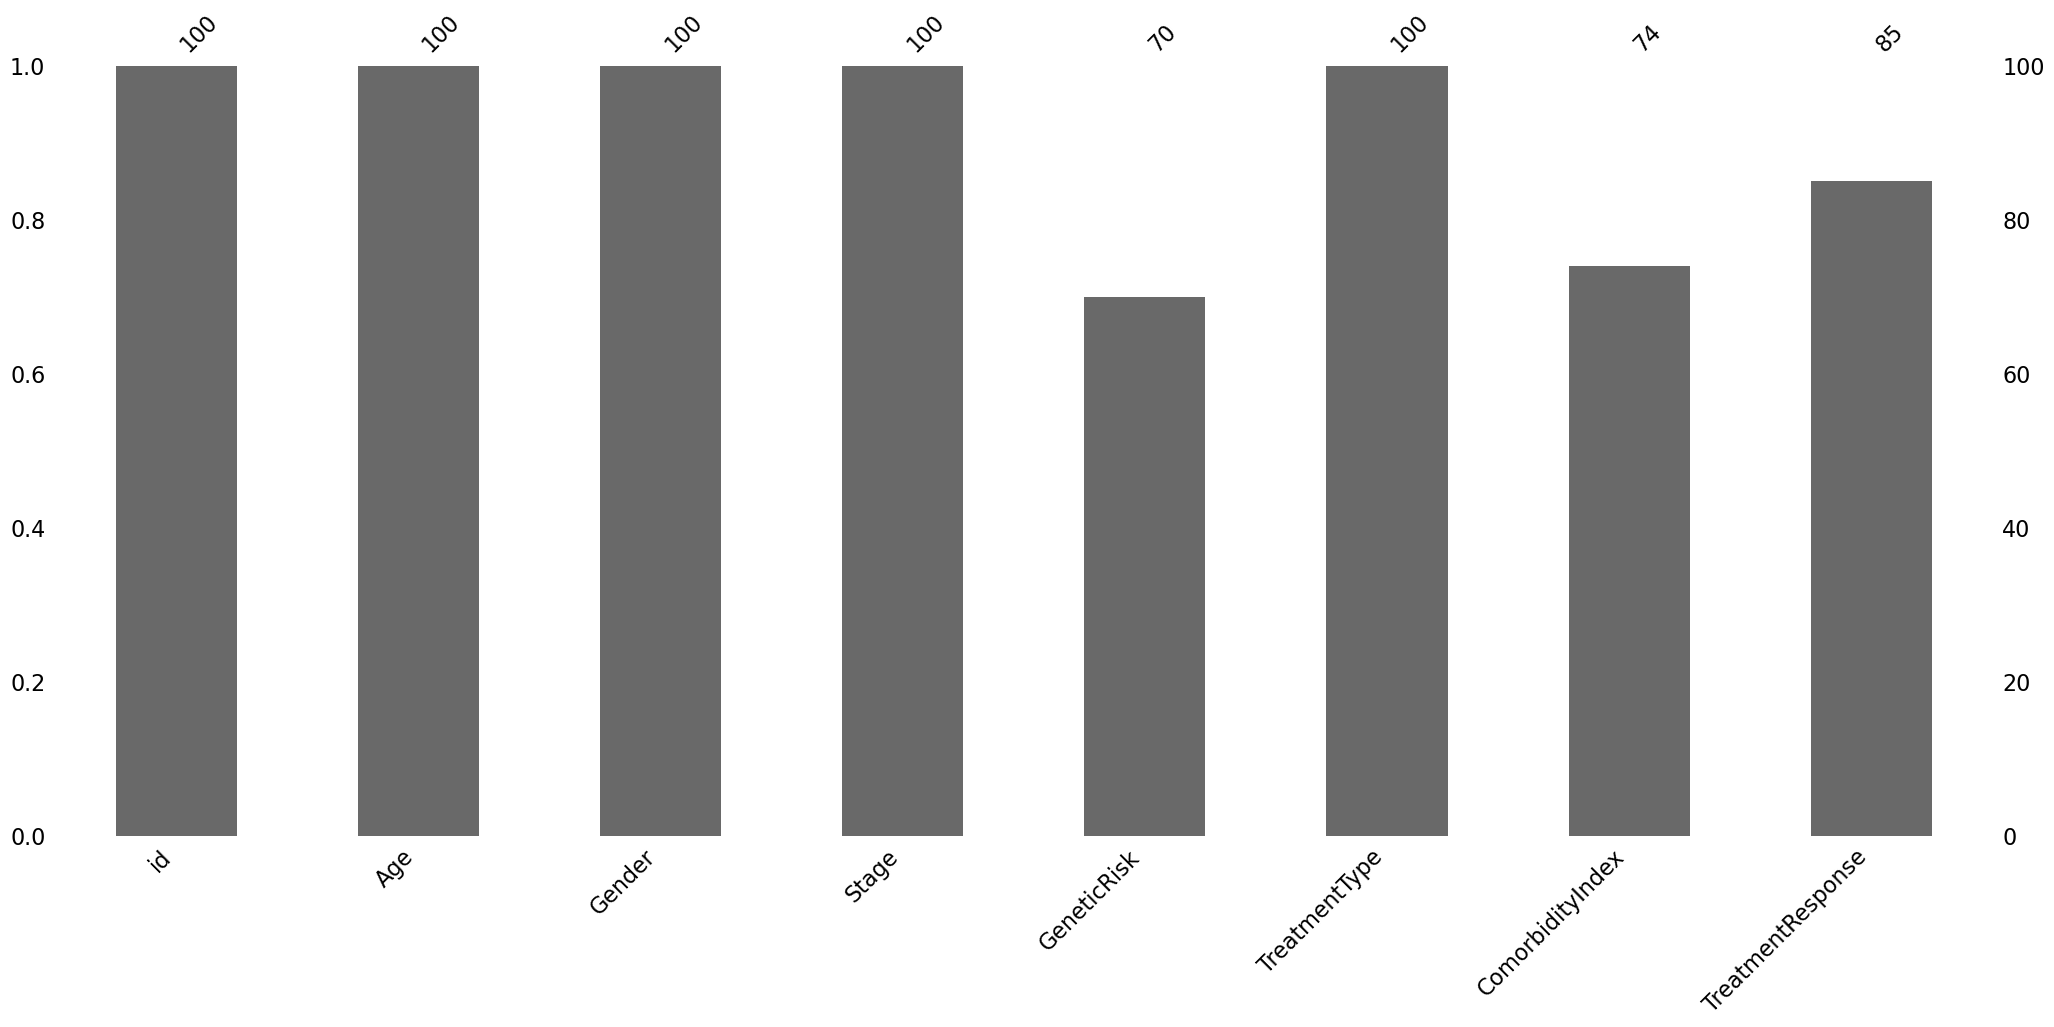

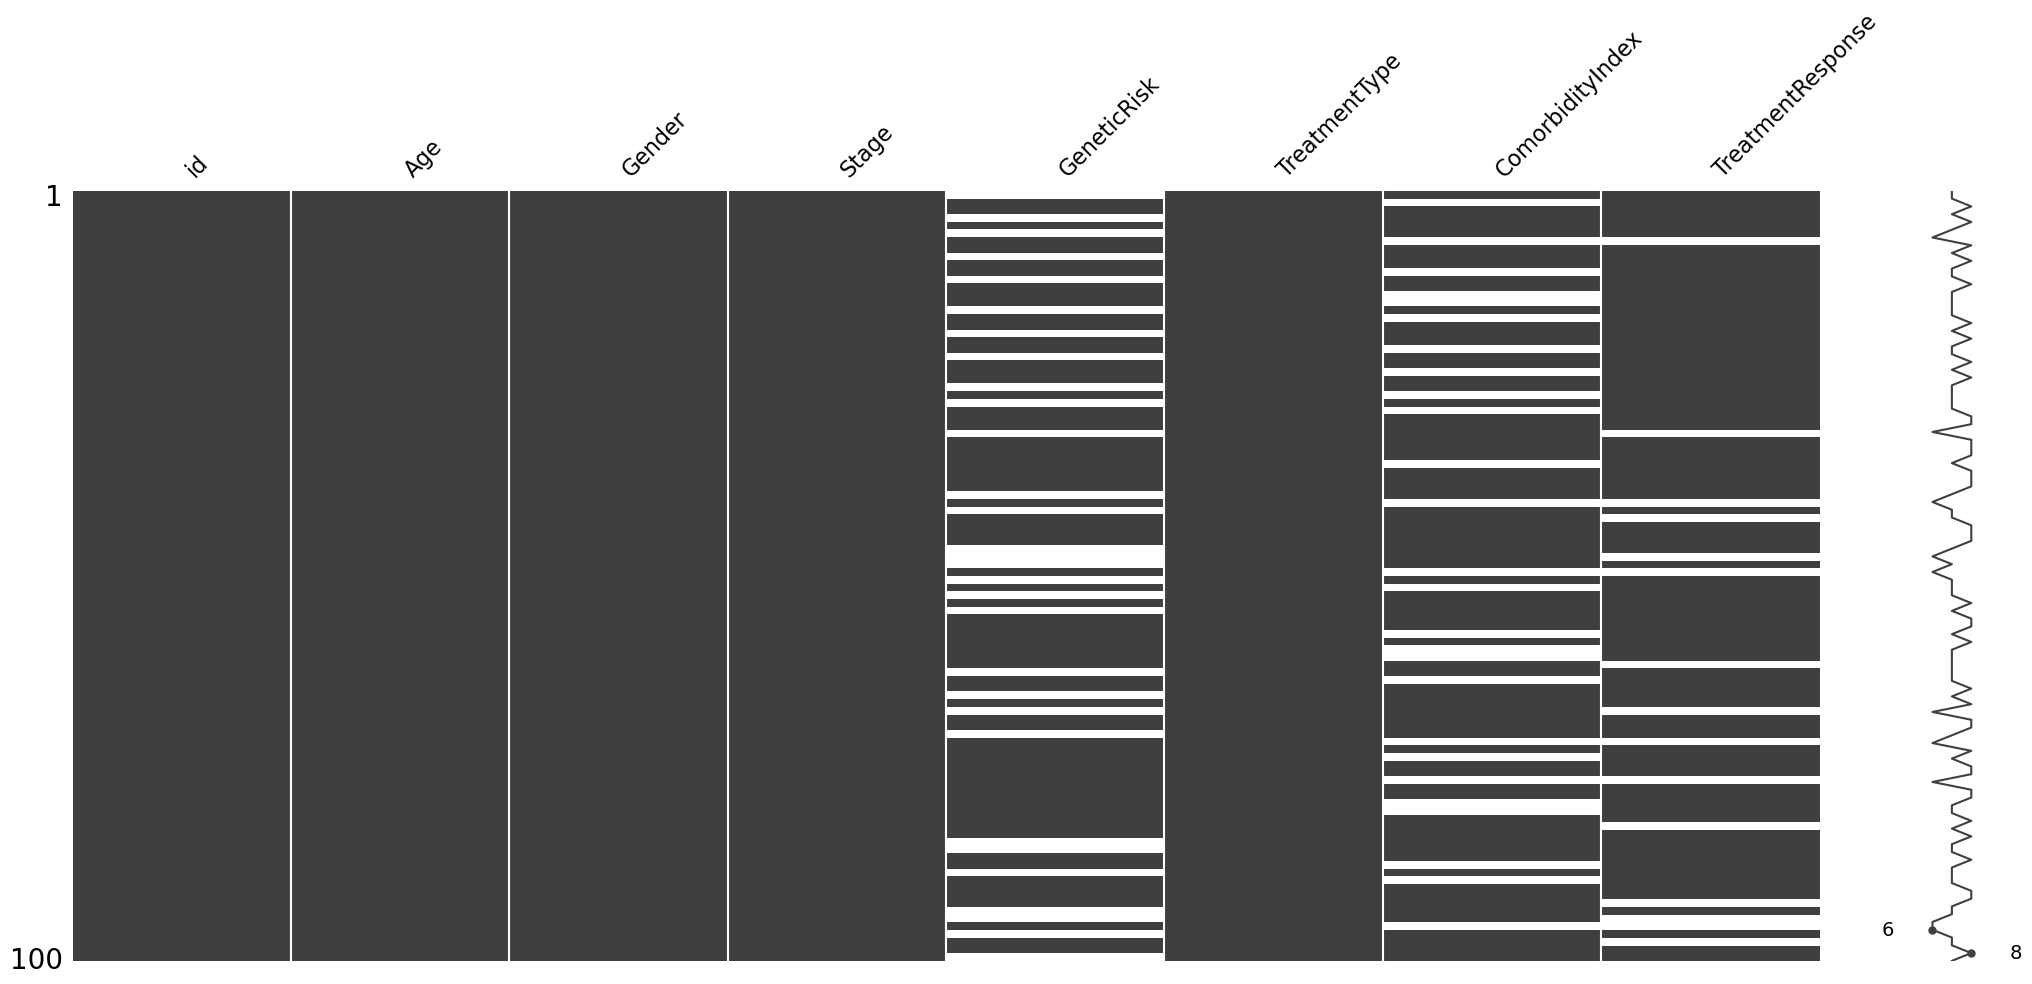

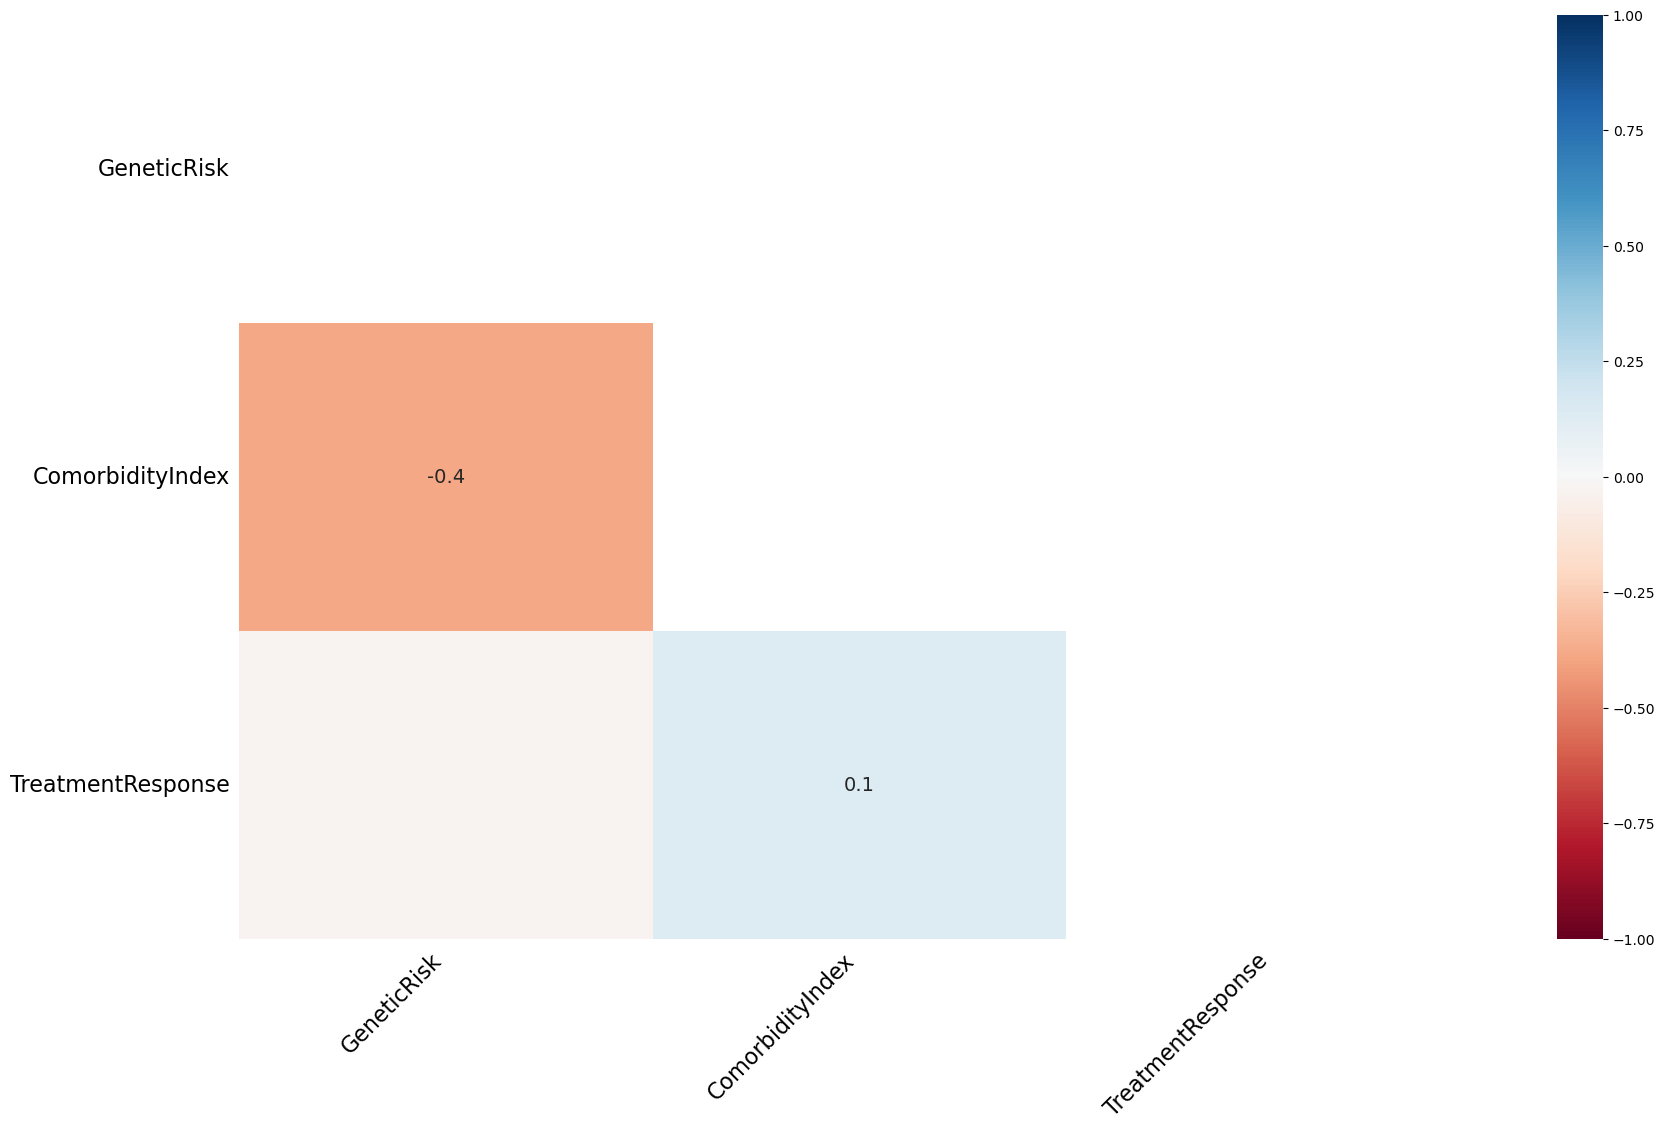

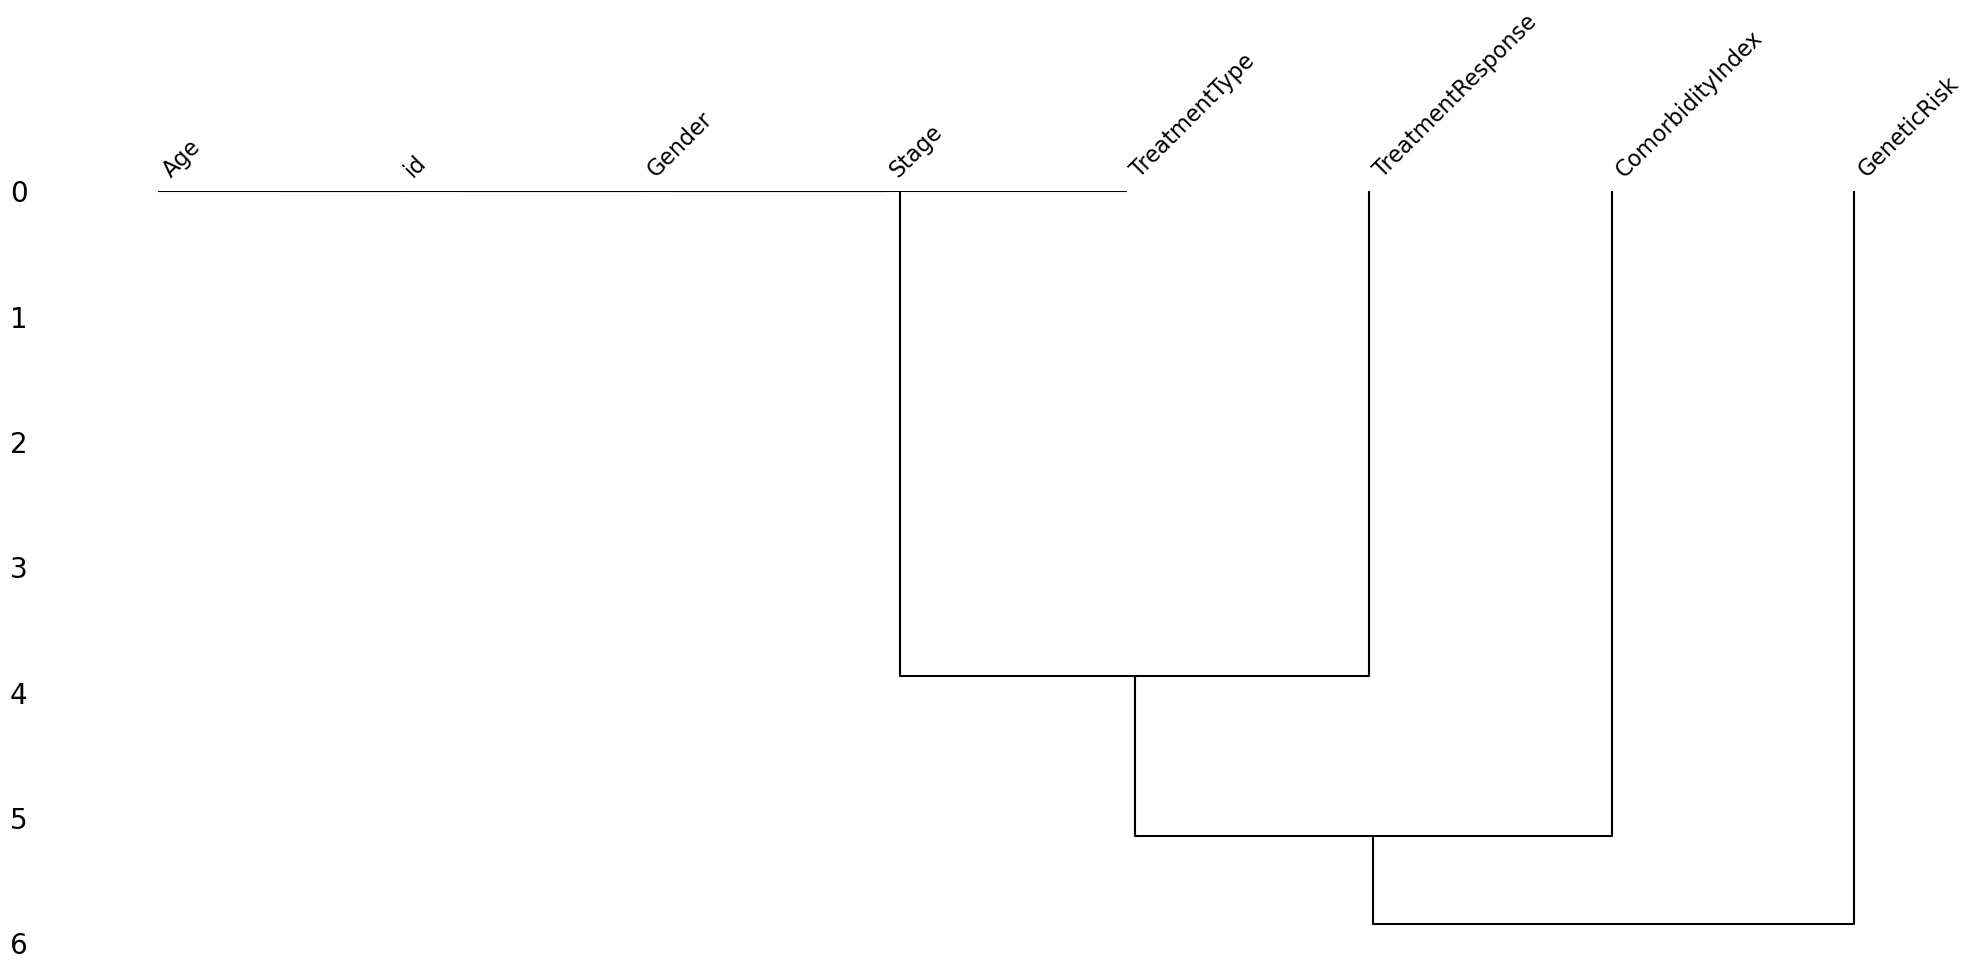

In [4]:
msno.bar(train_csv)
msno.matrix(train_csv)
msno.heatmap(train_csv)
msno.dendrogram(train_csv)

### Counting the Missing Values of each column

In [5]:
train_csv.isna().sum()

id                    0
Age                   0
Gender                0
Stage                 0
GeneticRisk          30
TreatmentType         0
ComorbidityIndex     26
TreatmentResponse    15
dtype: int64

### How many rows are there without any Missing Values?

In [6]:
train_wo_nan = train_csv.dropna() # I wrote w/o as without
num_rows = train_wo_nan["id"].nunique()
print(f"Total Number of cases: {num_rows}")

Total Number of cases: 39


### Initializing the Pairplot

In [7]:
## Initializing the pairplot
#sns.pairplot(train_wo_nan, kind="hist")
#plt.show()

In [ ]:
# TASK 1.1 — Identify columns with missing values and drop them

print("Original shape:", train_csv.shape)

missing_counts = train_csv.isna().sum().sort_values(ascending=False)
print("\nMissing counts (only columns with >0):")
print(missing_counts[missing_counts > 0])

cols_with_missing = missing_counts[missing_counts > 0].index.tolist()
print("\nColumns that contain missing values:", cols_with_missing)

# Drop columns that have any missing values
train_dropcols = train_csv.drop(columns=cols_with_missing)
print("Shape after dropping columns with ANY missing values:", train_dropcols.shape)
print("Remaining columns:", train_dropcols.columns.tolist())

# Now try to remove censored and missing-target rows if possible
target_col = "SurvivalTime"
censor_col = "censored"

has_target = target_col in train_csv.columns
has_censor = censor_col in train_csv.columns

if not has_target:
    print("\nNOTE: 'SurvivalTime' not found in train_csv. We cannot filter rows by label or censoring.")
else:
    labeled_count = train_csv[target_col].notna().sum()
    unlabeled_count = train_csv[target_col].isna().sum()
    print(f"\nIf present: labeled (SurvivalTime present): {labeled_count}, unlabeled: {unlabeled_count}")
    # Filter to rows with target present
    train_labeled = train_csv[train_csv[target_col].notna()].copy()
    if has_censor:
        train_labeled_uncensored = train_labeled[train_labeled[censor_col].astype(bool) == False].copy()
        print("Rows with SurvivalTime AND uncensored:", train_labeled_uncensored.shape[0])
    else:
        print("No 'censored' column present; cannot filter censored rows.")


Original shape: (100, 8)

Missing counts (only columns with >0):
GeneticRisk          30
ComorbidityIndex     26
TreatmentResponse    15
dtype: int64

Columns that contain missing values: ['GeneticRisk', 'ComorbidityIndex', 'TreatmentResponse']
Shape after dropping columns with ANY missing values: (100, 5)
Remaining columns: ['id', 'Age', 'Gender', 'Stage', 'TreatmentType']

NOTE: 'SurvivalTime' not found in train_csv. We cannot filter rows by label or censoring.


### Task 1.2 Learn the baseline model

## Task 2 Nonlinear models

### Task 2.1 Development

### Task 2.2 Evaluation

## Task 3 Handling missing data

### Task 3.1 Missing data imputation

### Task 3.2 Train models that do not require imputation

### Task 3.3 Evaluation

## Task 4 Semi-supervised learning for unlabeled data

### Task 4.1 Imputation with labeled and unlabeled data

### Task 4.2 Evaluation

## Task 5 [optional]